In [2]:
import math
import matplotlib.pyplot as plt
import torch

In [3]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import datasets
import utils

In [4]:
def _log_normal_diag(X, mus, var, eps=1e-6):
    var = var.clamp_min(eps)
    D = X.shape[-1]
    diff2 = (X[:, None, :] - mus[None, :, :]) ** 2
    norm = -0.5 * D * math.log(2.0 * math.pi)
    log_det = -0.5 * torch.log(var).sum(dim=-1)[None, :]
    quad = -0.5 * (diff2 / var[None, :, :]).sum(dim=-1)
    log_prob = norm + log_det + quad
    return log_prob

@torch.no_grad()
def gmmil_em(X, y, K=1, K_prime=1, iters=50, eps=1e-6):

    N, D = X.shape
    M = K + K_prime

    device, dtype = X.device, X.dtype

    y0 = (y == 0)
    y1 = (y == 1)

    N0 = int(y0.sum().item())
    N1 = int(y1.sum().item())
    
    pi_0 = torch.full((K,), 1.0 / K, device=device, dtype=dtype)
    pi_1 = torch.full((M,), 1.0 / M, device=device, dtype=dtype)
    perm_y0 = torch.randperm(len(X[y0]), device=device)
    perm_y1 = torch.randperm(len(X[y1]), device=device)
    mus = torch.cat([
        X[y0][perm_y0[:K]].clone(), 
        X[y1][perm_y1[:K_prime]].clone()
    ])
    global_var = X.var(dim=0, unbiased=False).clamp_min(eps)
    var = global_var.repeat(M, 1).clone()

    loglik_hist = []

    for _ in range(iters):
        
        # E-step
        log_probs = _log_normal_diag(X, mus, var, eps=eps)

        log_pis = torch.full((N, M), float("-inf"), device=device, dtype=dtype)
        log_pis[y0, :K] = torch.log(pi_0.clamp_min(eps))[None, :]
        log_pis[y1, :] = torch.log(pi_1.clamp_min(eps))[None, :]

        log_joint = log_pis + log_probs
        log_norm = torch.logsumexp(log_joint, dim=1, keepdim=True)
        R = torch.exp(log_joint - log_norm)

        loglik = log_norm.sum().item()
        loglik_hist.append(loglik)

        # M-step
        R0 = R[y0, :K]
        Nk0 = R0.sum(dim=0).clamp_min(eps)
        pi_0 = (Nk0 / Nk0.sum()).contiguous()
        
        R1 = R[y1, :]
        Nk1 = R1.sum(dim=0).clamp_min(eps)
        pi_1 = (Nk1 / Nk1.sum()).contiguous()

        Nk = R.sum(dim=0).clamp_min(eps)

        mus = (R.T @ X) / Nk[:, None]

        diff = X[:, None, :] - mus[None, :, :]
        var = (R[:, :, None] * diff.pow(2)).sum(dim=0) / Nk[:, None]
        var = var.clamp_min(eps)

    return pi_0, pi_1, mus, var, loglik_hist

In [5]:
#train_dataset = datasets.ShiftedMeanMILDataset(N=1000, R=3, Delta=2.0, seed=0)
#test_dataset = datasets.ShiftedMeanMILDataset(N=1000, R=3, Delta=2.0, seed=2)

#X_train, lengths_train, y_train = train_dataset.H, train_dataset.lengths, train_dataset.y
#X_test, lengths_test, y_test = test_dataset.H, test_dataset.lengths, test_dataset.y

dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16/seed=1001'
train_data = torch.load(f'{dataset_dir}/train.pth', map_location=torch.device('cpu'))
val_data = torch.load(f'{dataset_dir}/val.pth', map_location=torch.device('cpu'))
test_data = torch.load(f'{dataset_dir}/test.pth', map_location=torch.device('cpu'))

X_train, lengths_train, y_train = train_data['X'], train_data['lengths'], train_data['y']
X_val, lengths_val, y_val = val_data['X'], val_data['lengths'], val_data['y']
X_test, lengths_test, y_test = test_data['X'], test_data['lengths'], test_data['y']

y_train_expanded = y_train.repeat_interleave(torch.tensor(lengths_train, device=y_train.device))
y_test_expanded = y_test.repeat_interleave(torch.tensor(lengths_test, device=y_test.device))

K, K_prime = 1, 1

pi_0, pi_1, mus, var, loglik_hist = gmmil_em(X_train, y_train_expanded, K=K, K_prime=K_prime, iters=50, eps=1e-6)


In [ ]:
mus[0,j]

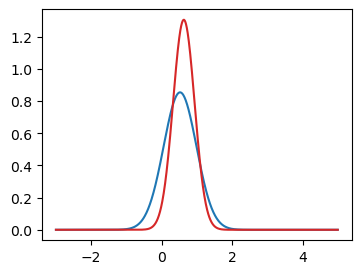

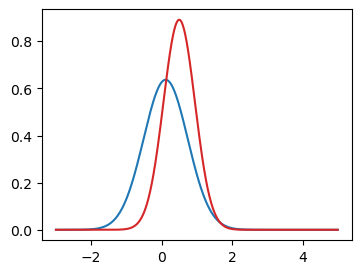

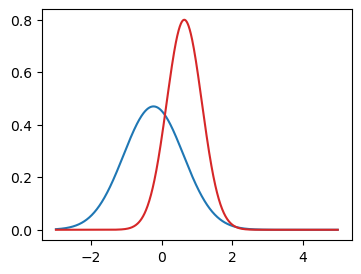

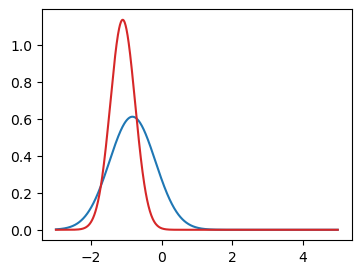

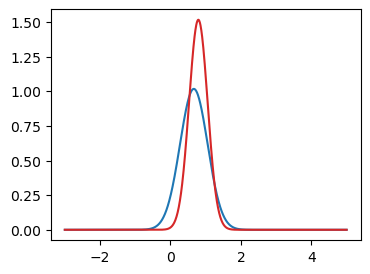

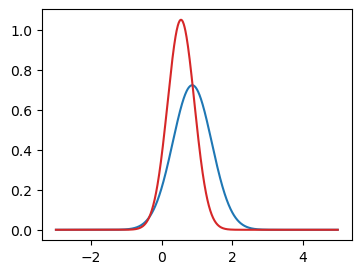

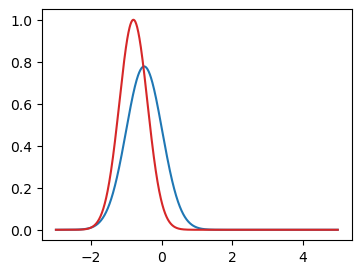

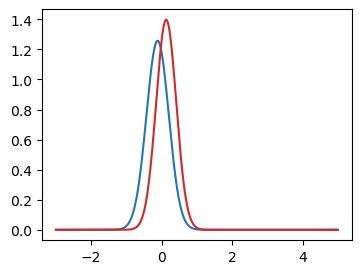

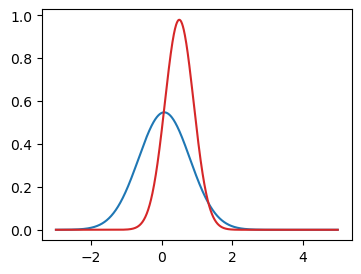

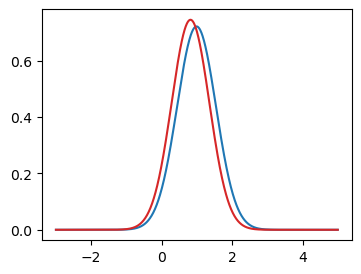

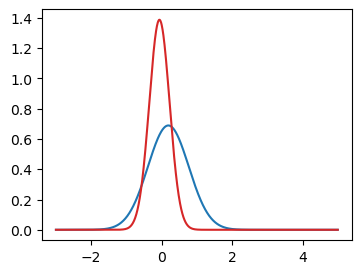

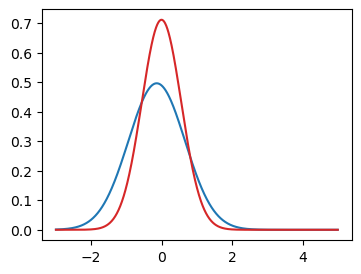

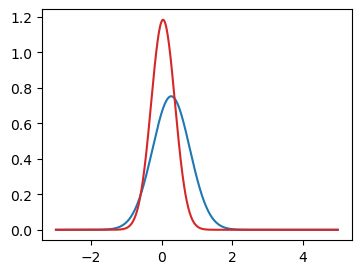

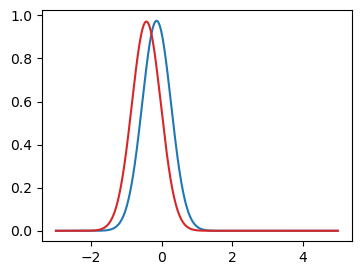

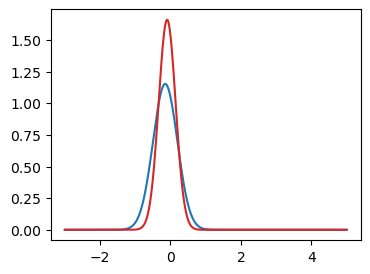

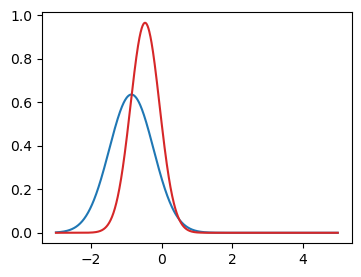

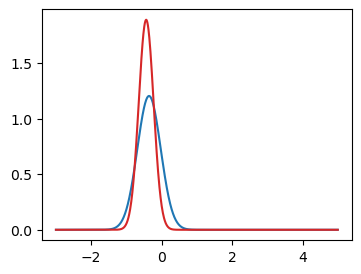

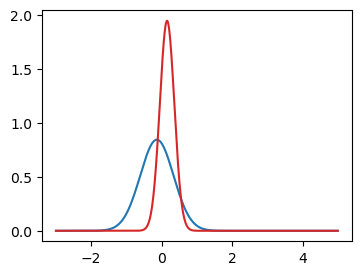

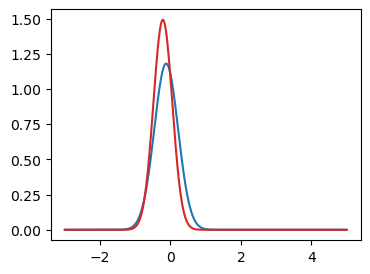

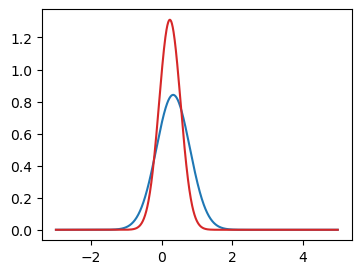

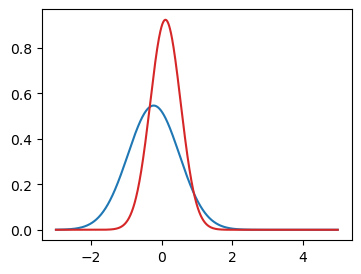

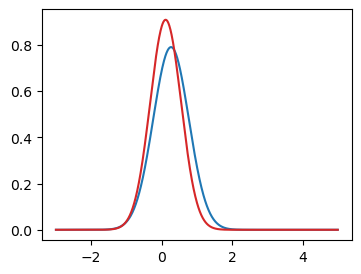

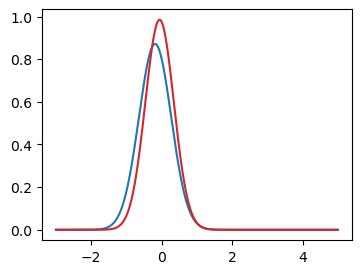

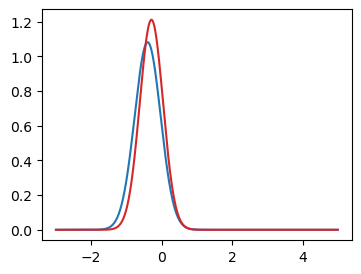

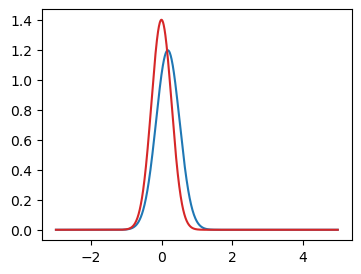

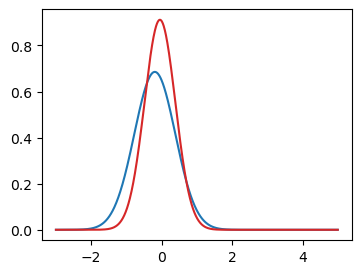

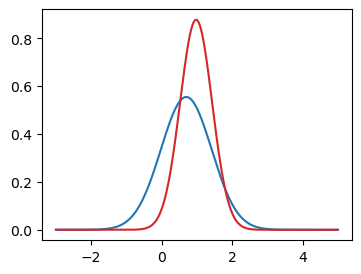

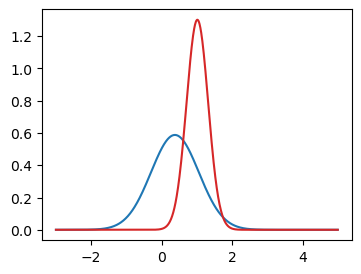

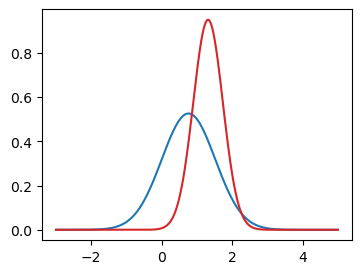

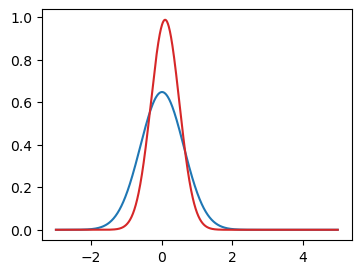

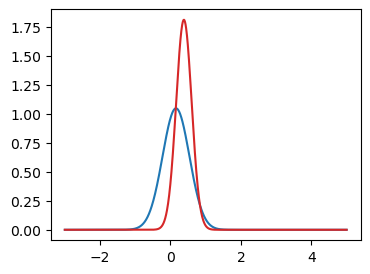

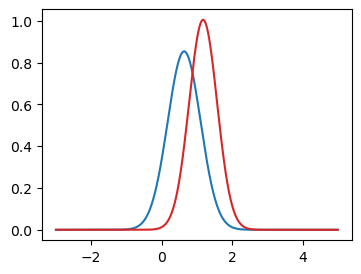

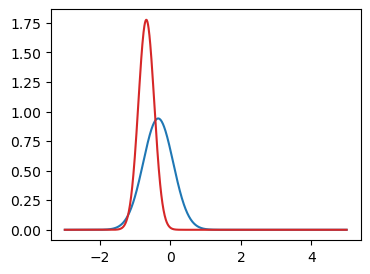

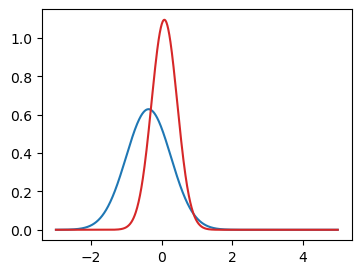

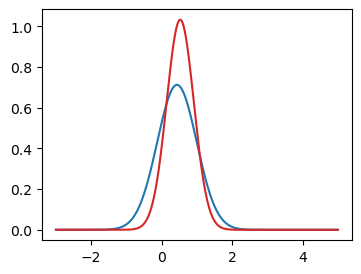

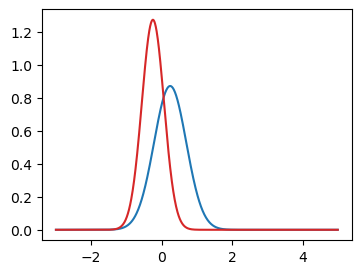

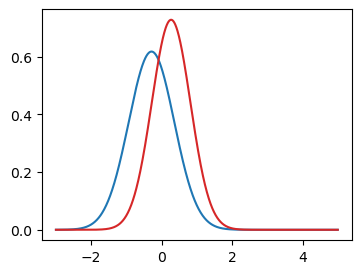

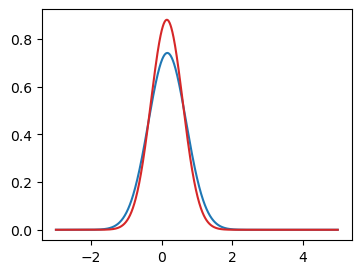

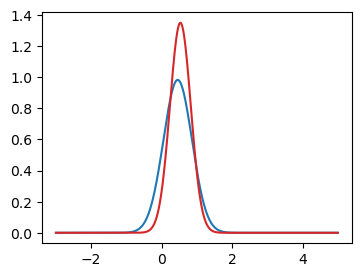

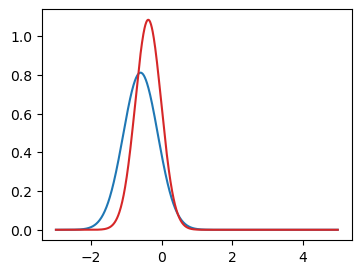

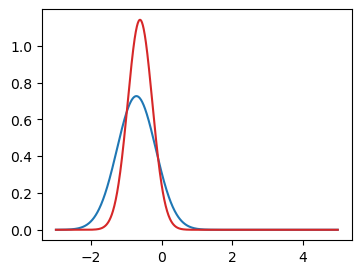

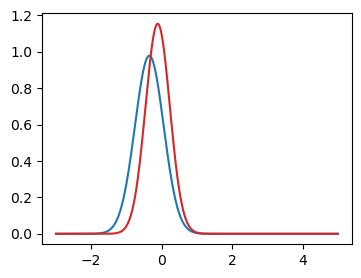

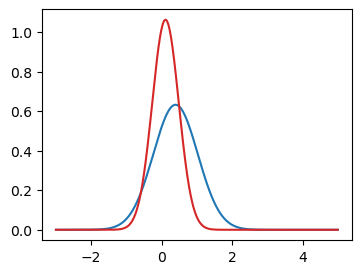

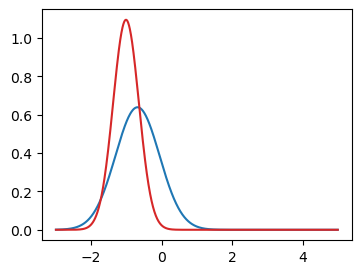

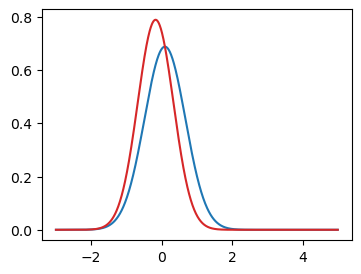

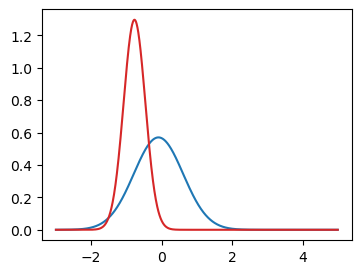

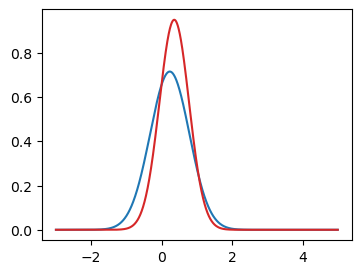

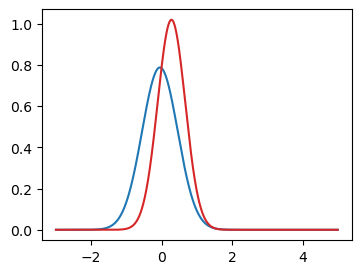

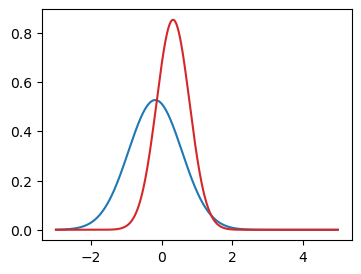

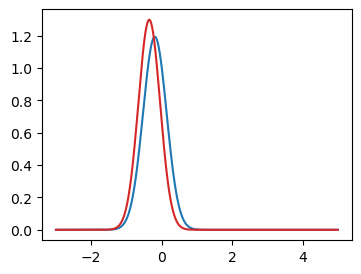

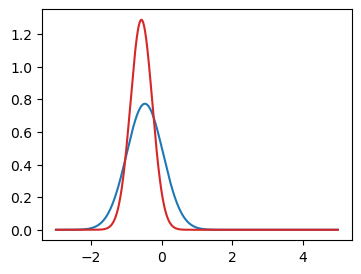

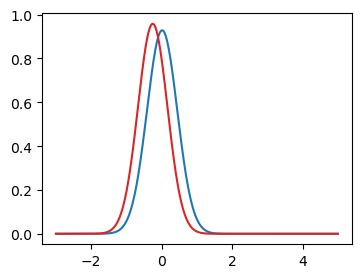

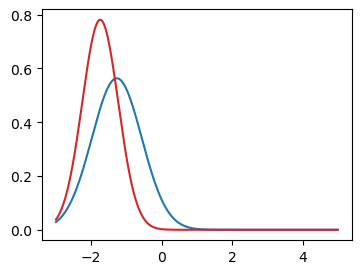

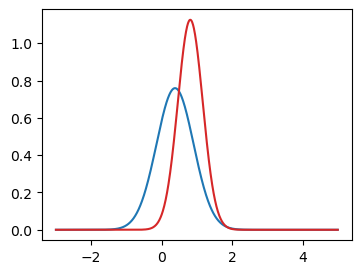

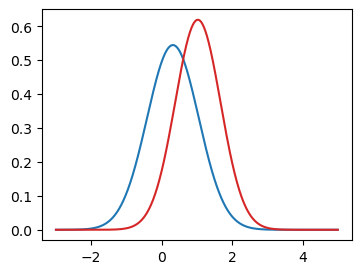

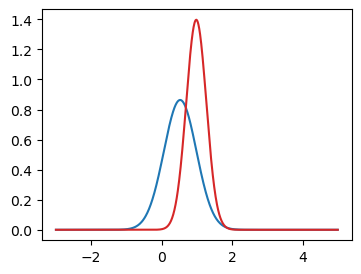

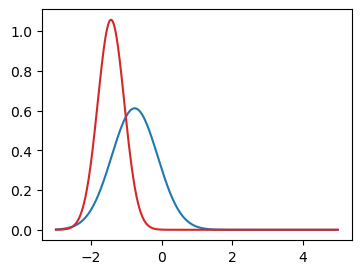

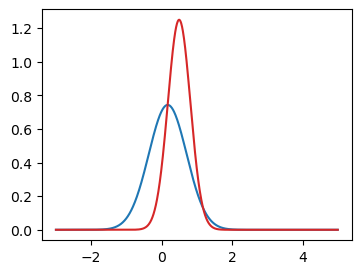

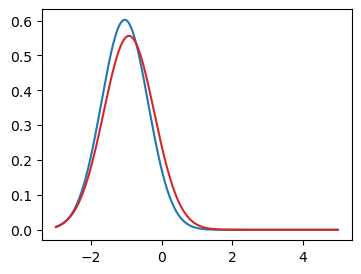

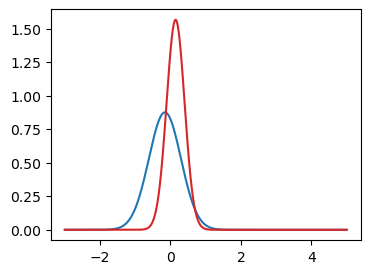

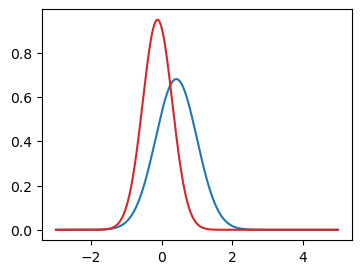

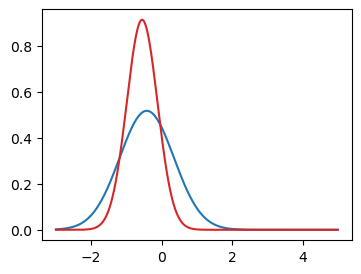

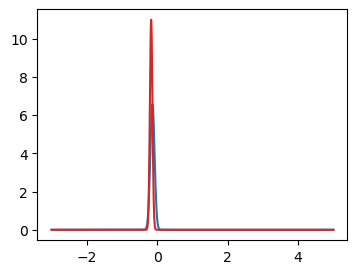

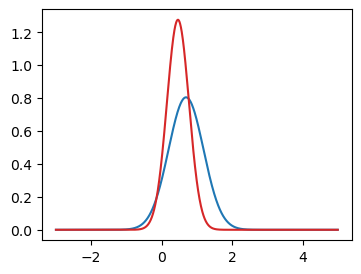

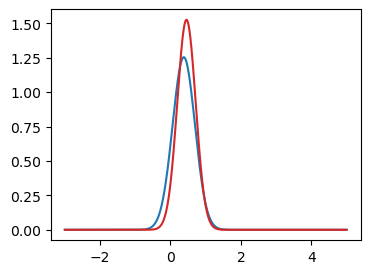

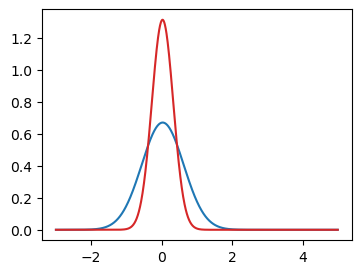

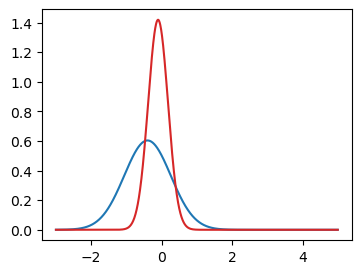

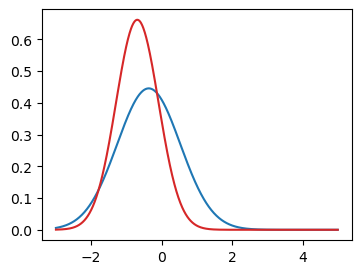

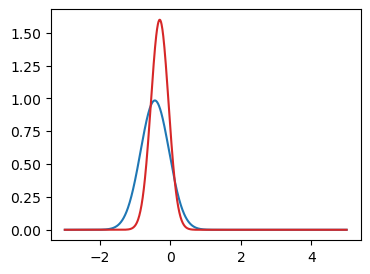

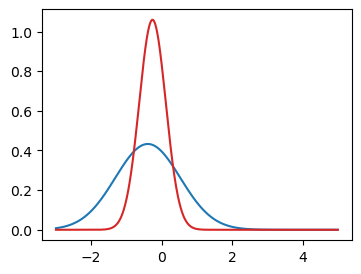

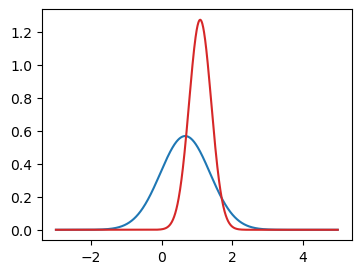

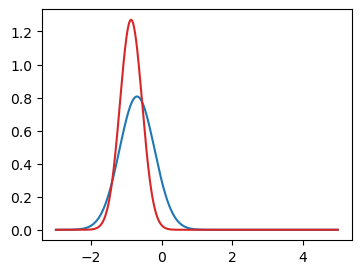

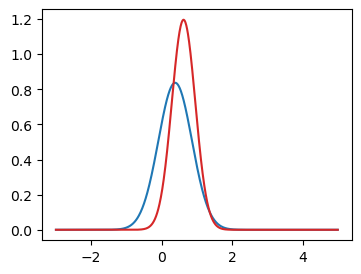

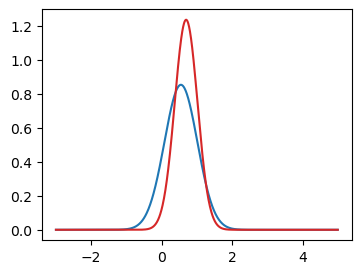

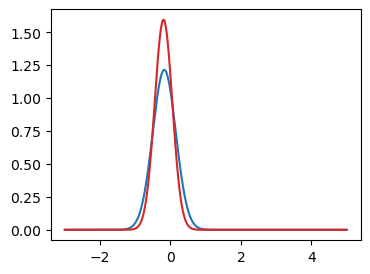

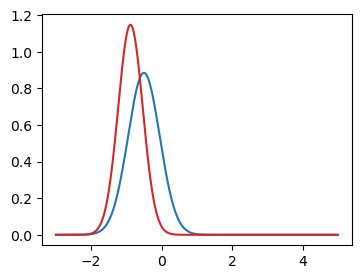

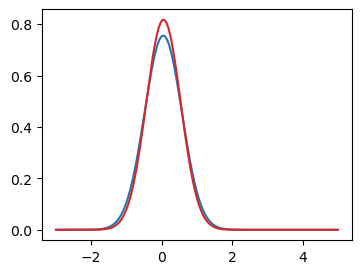

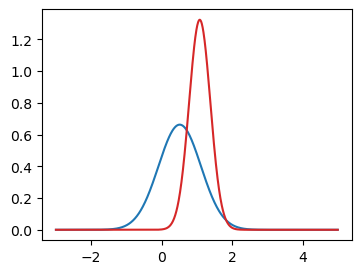

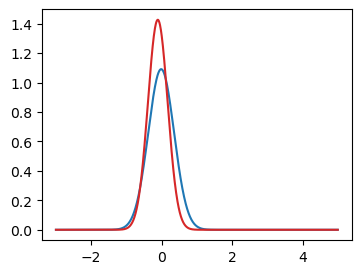

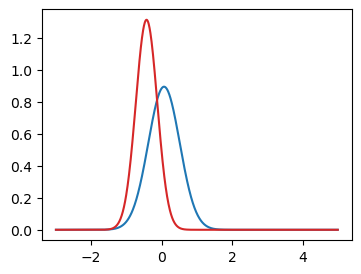

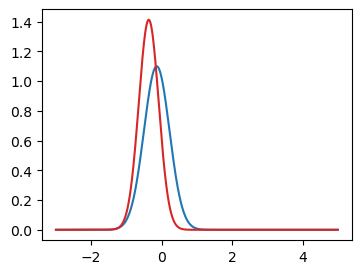

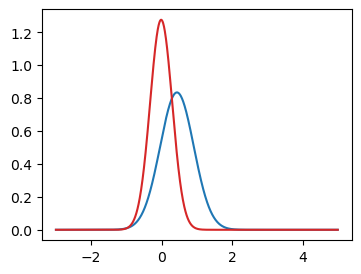

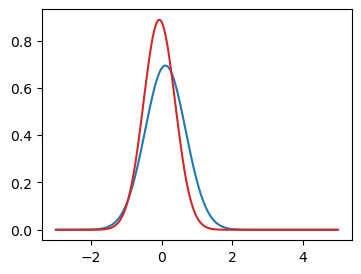

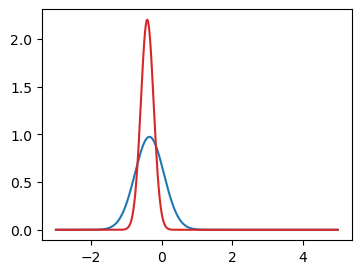

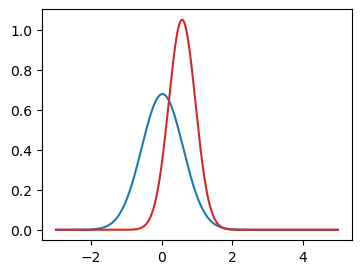

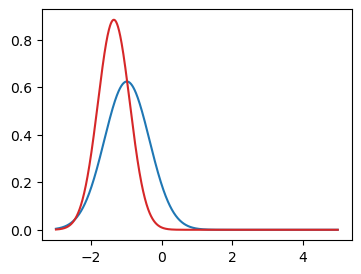

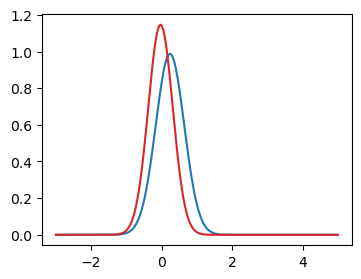

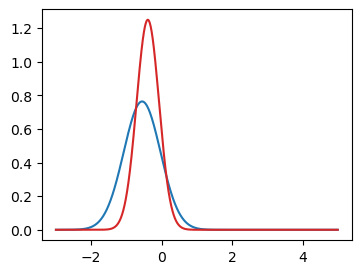

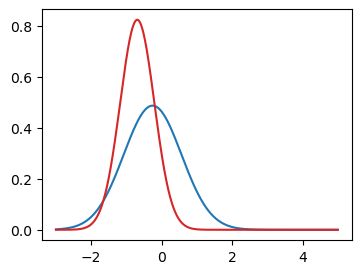

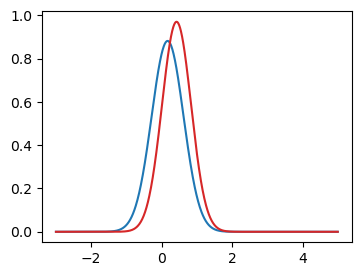

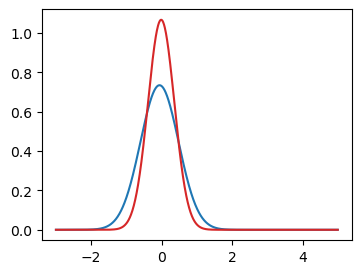

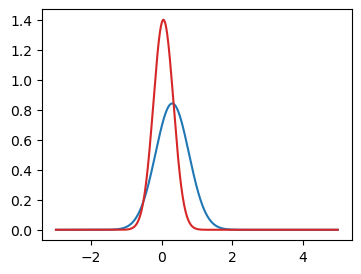

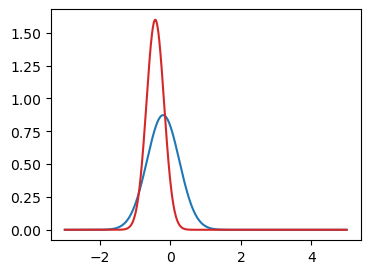

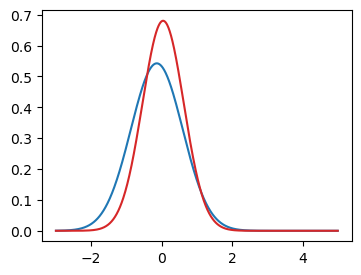

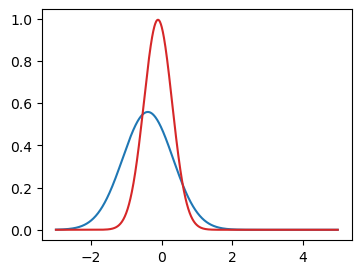

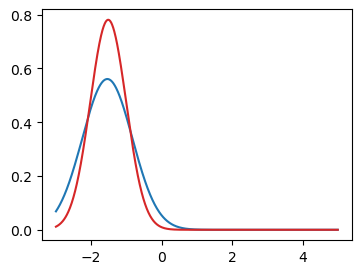

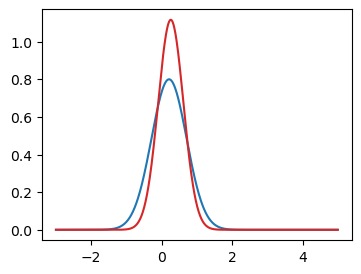

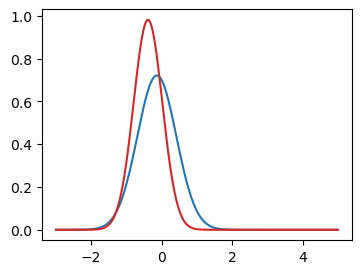

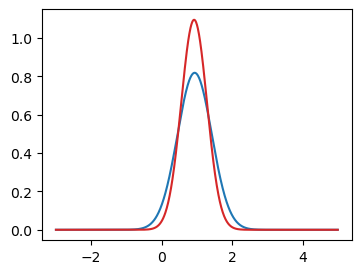

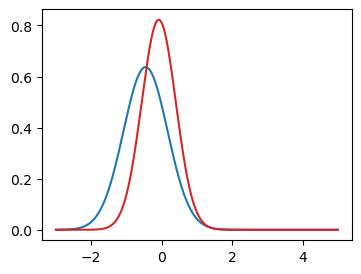

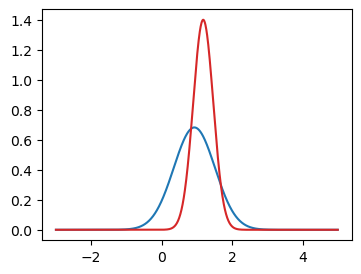

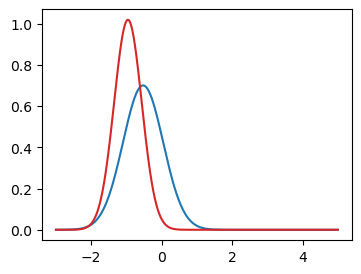

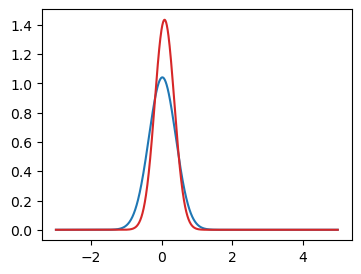

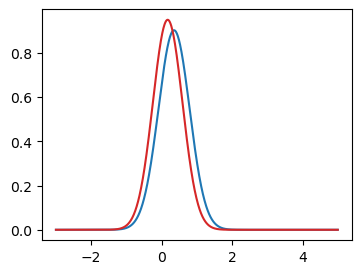

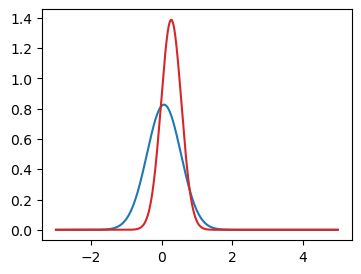

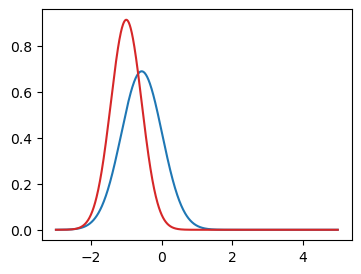

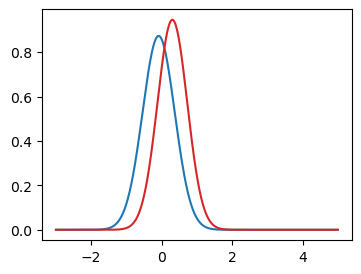

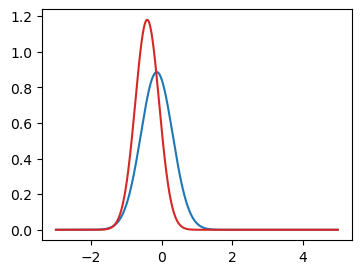

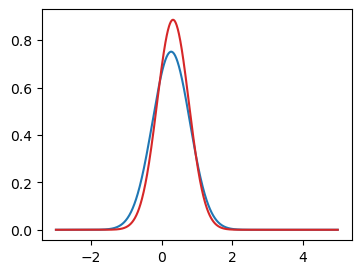

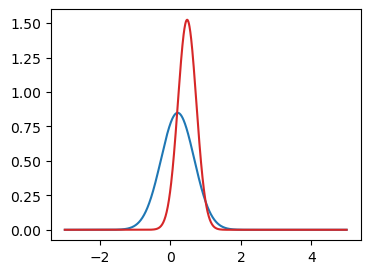

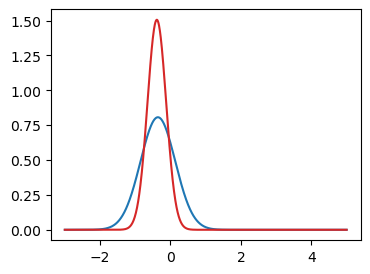

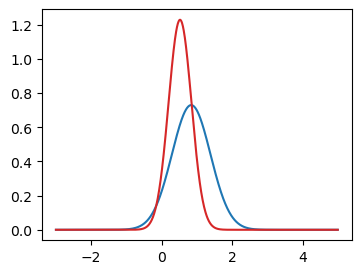

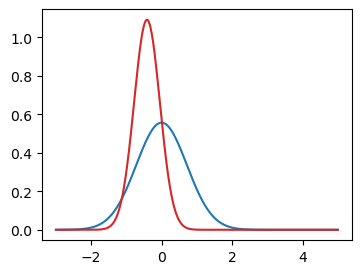

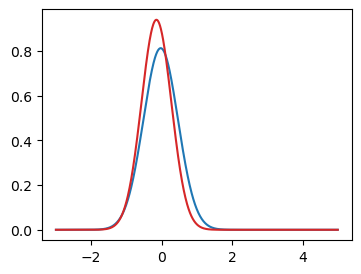

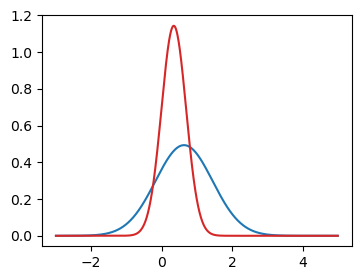

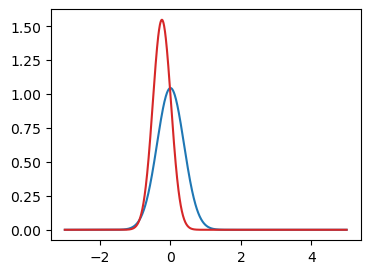

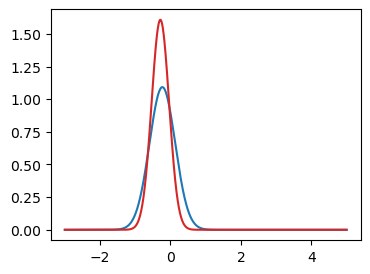

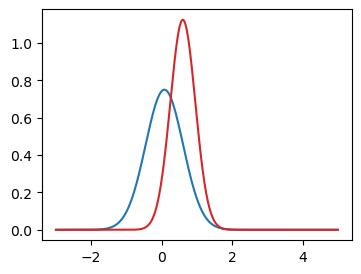

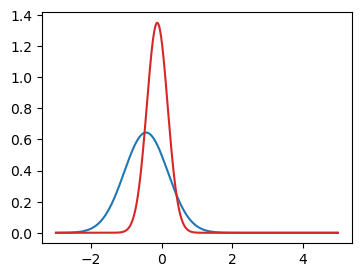

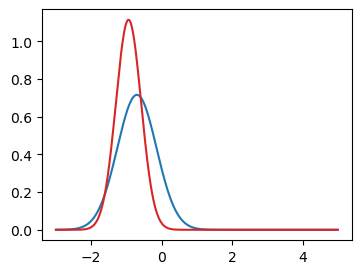

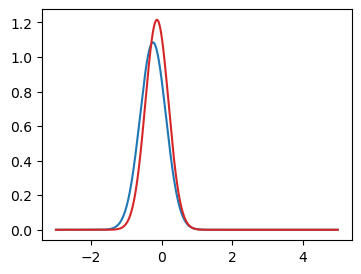

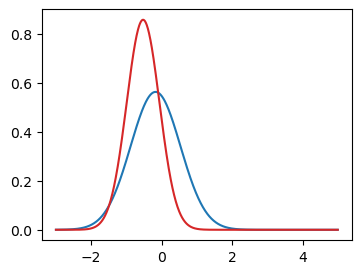

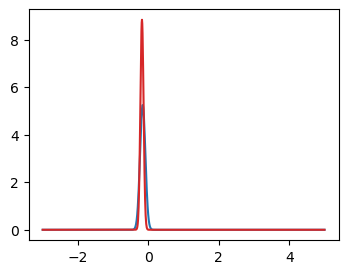

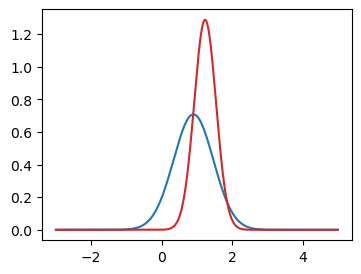

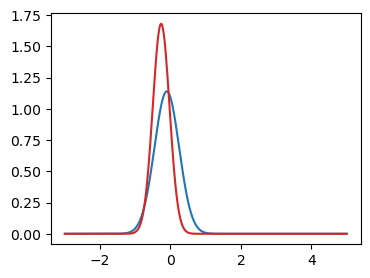

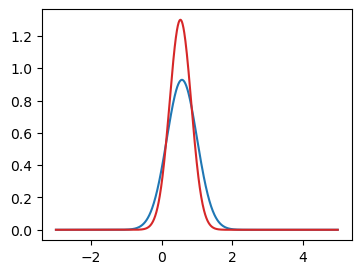

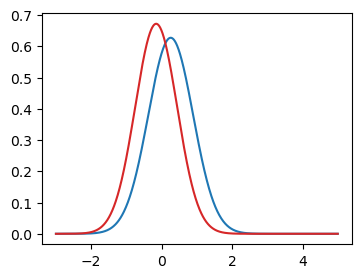

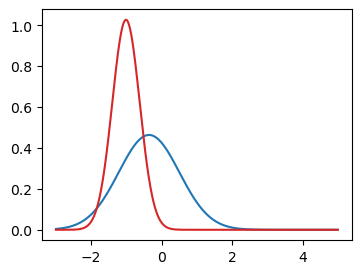

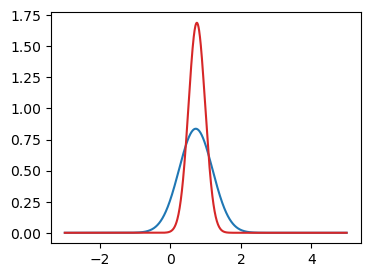

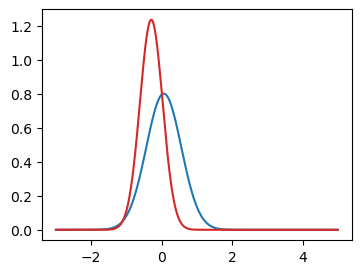

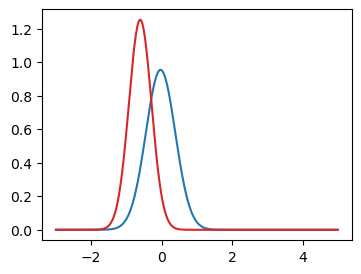

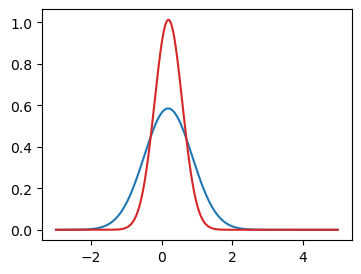

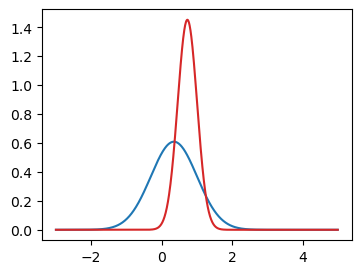

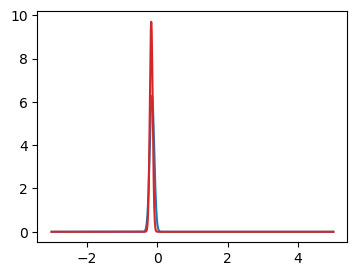

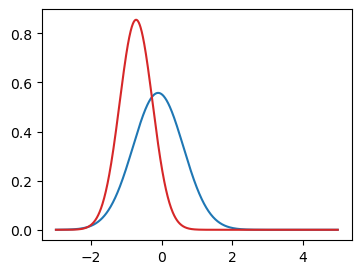

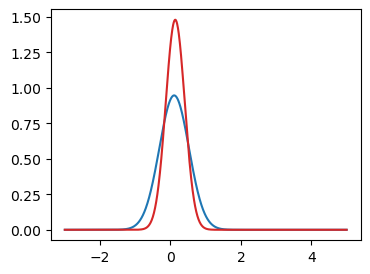

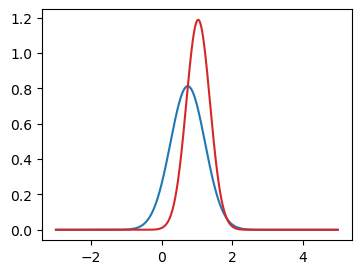

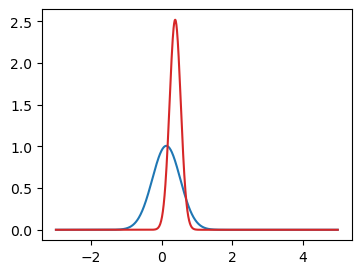

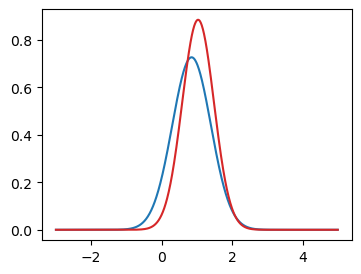

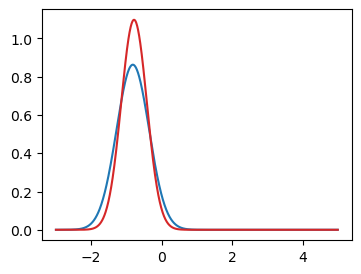

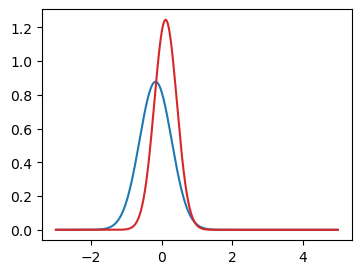

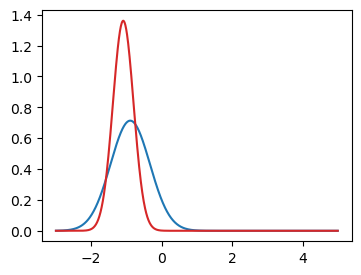

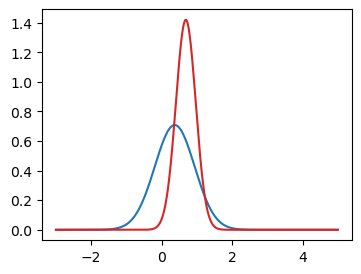

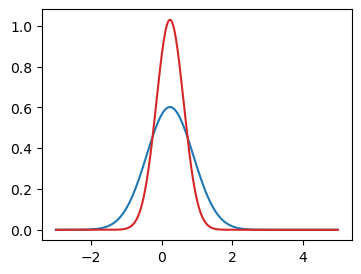

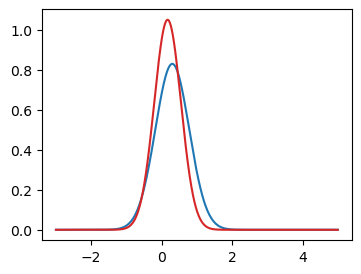

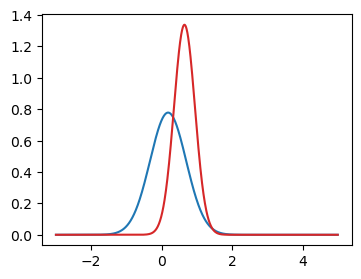

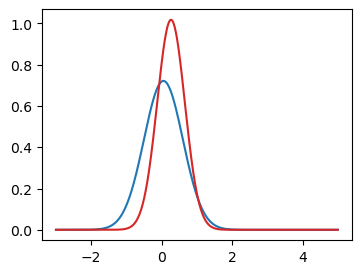

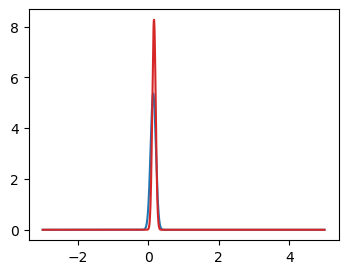

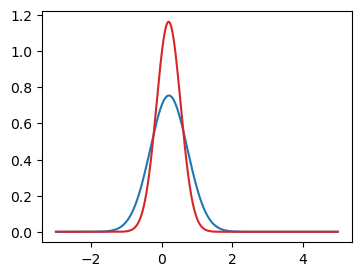

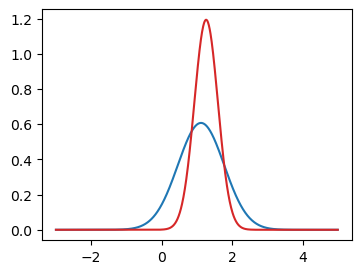

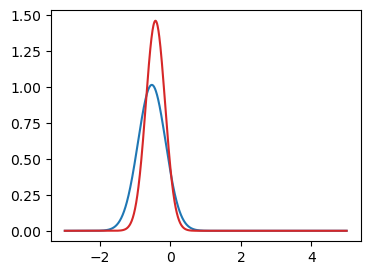

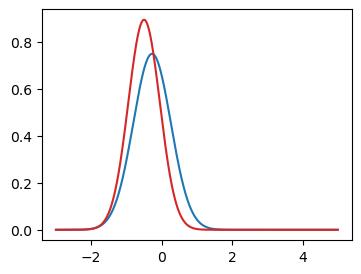

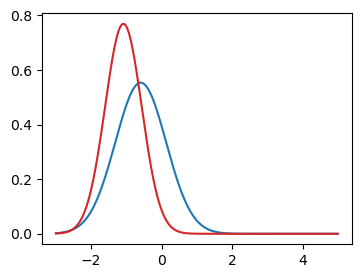

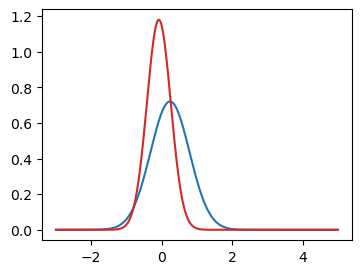

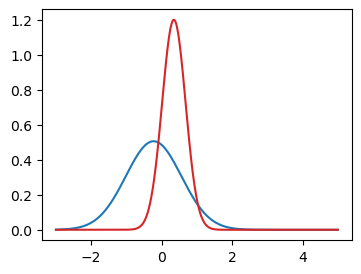

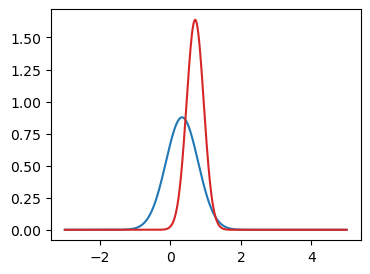

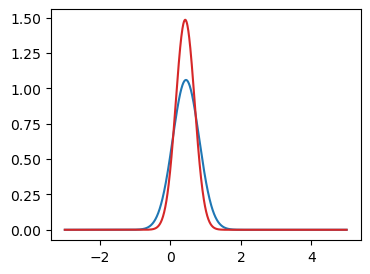

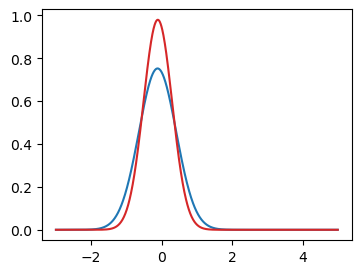

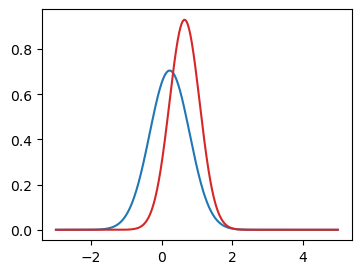

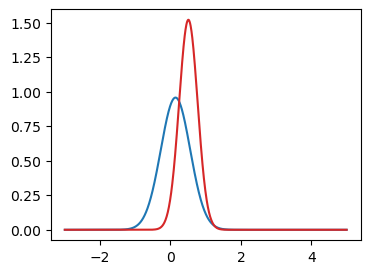

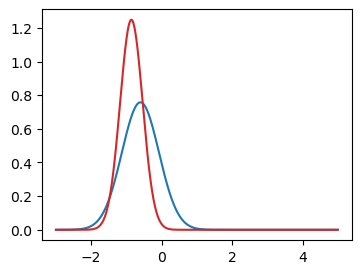

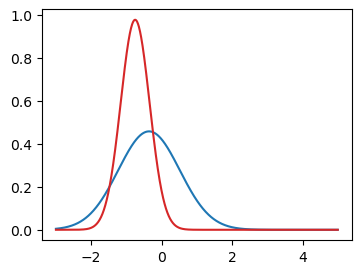

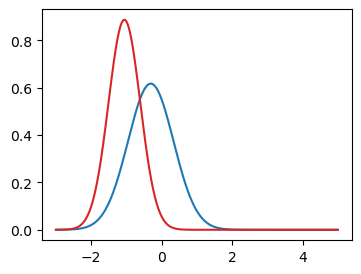

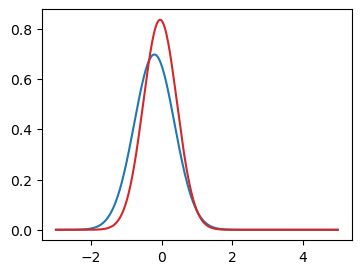

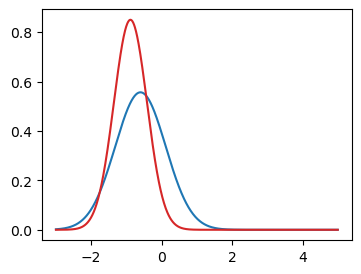

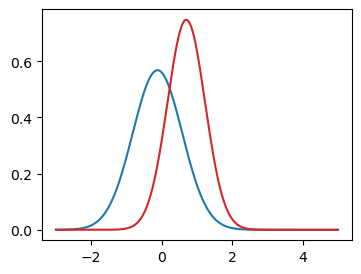

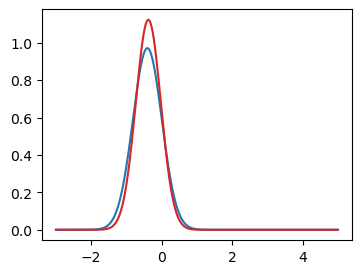

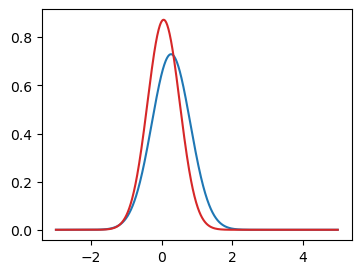

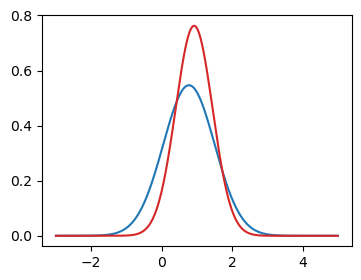

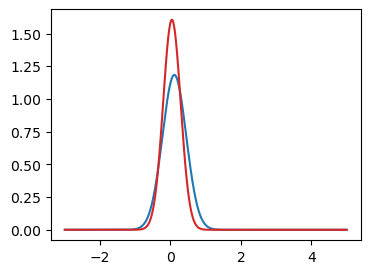

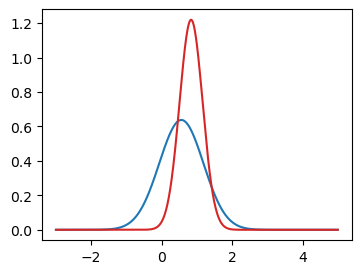

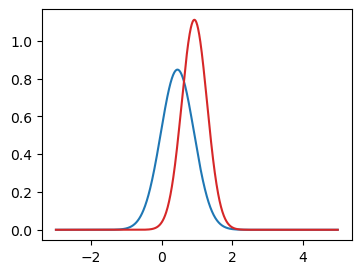

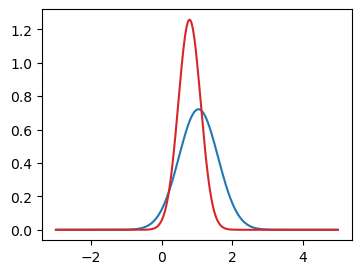

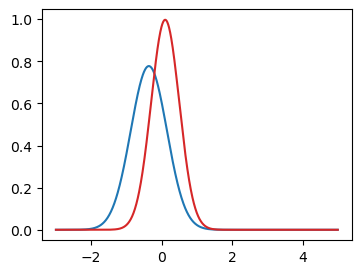

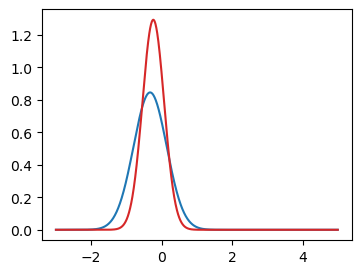

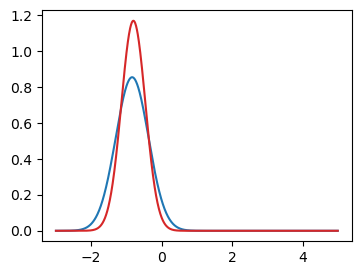

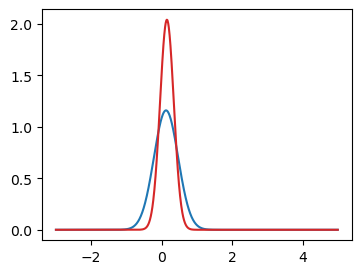

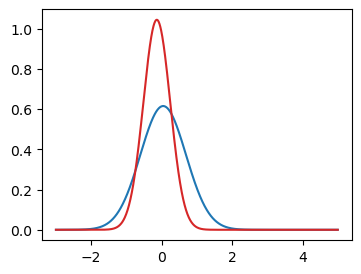

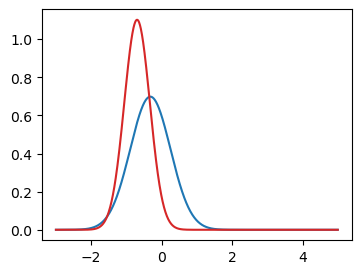

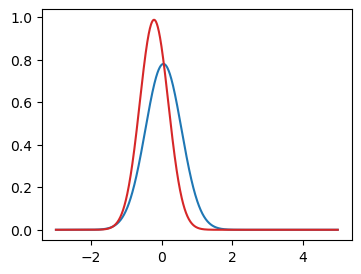

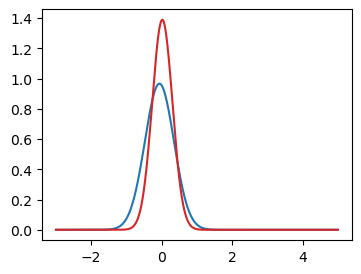

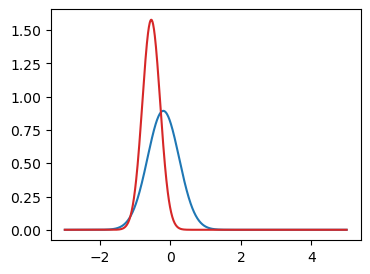

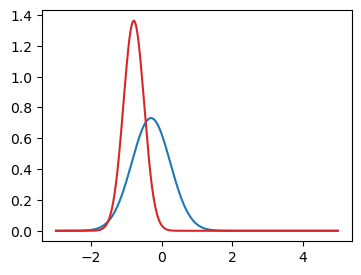

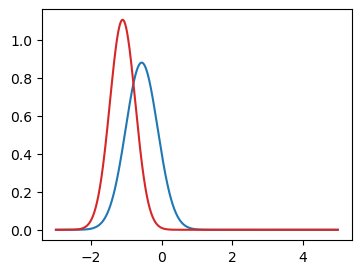

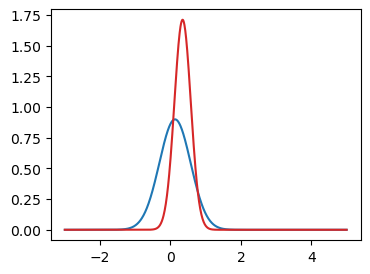

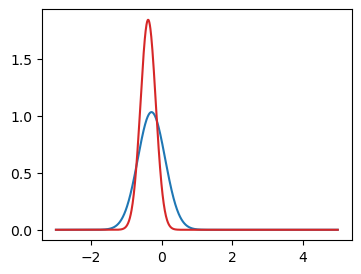

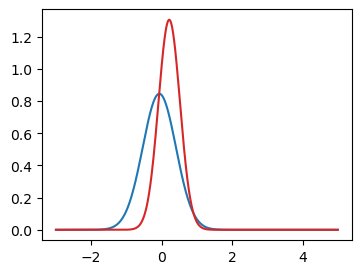

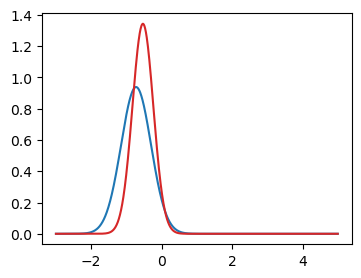

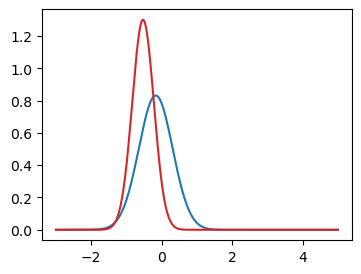

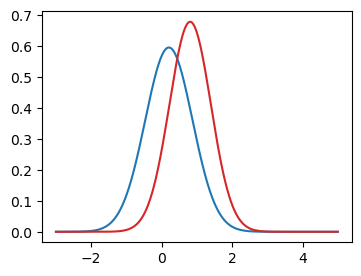

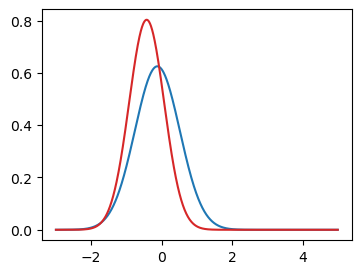

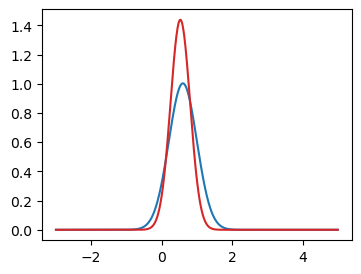

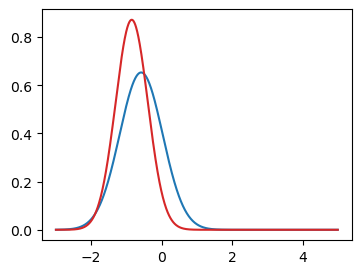

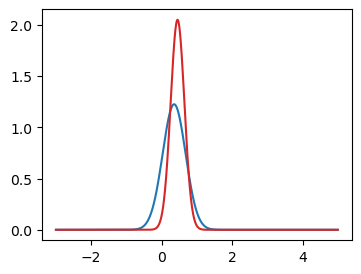

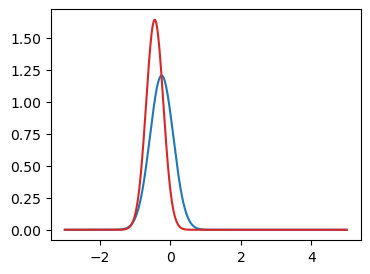

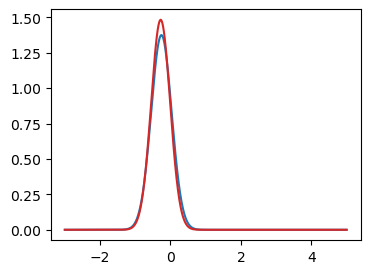

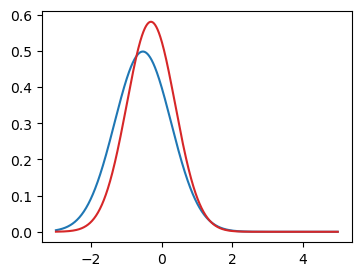

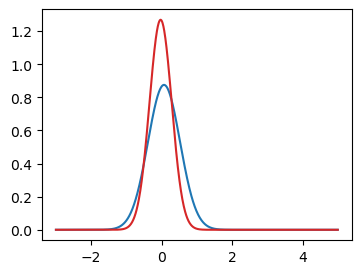

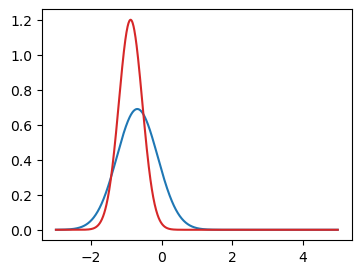

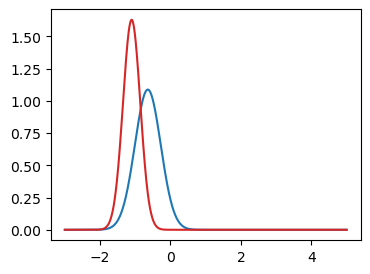

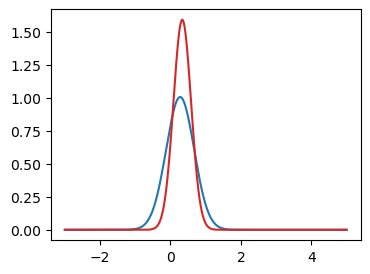

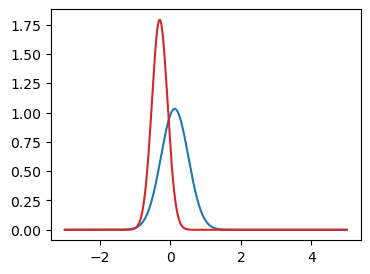

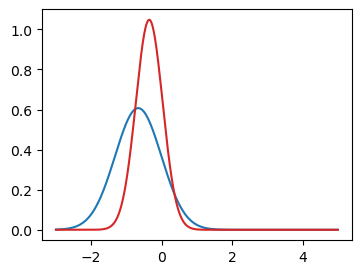

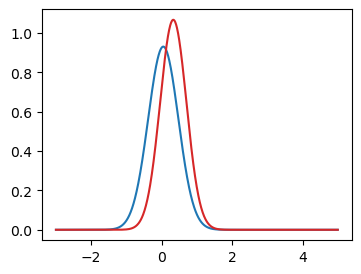

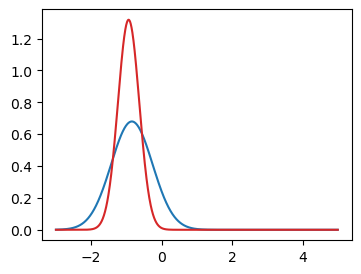

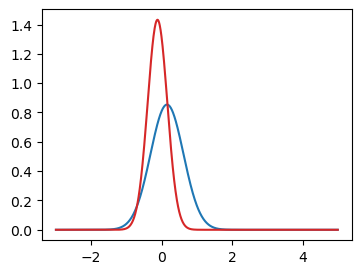

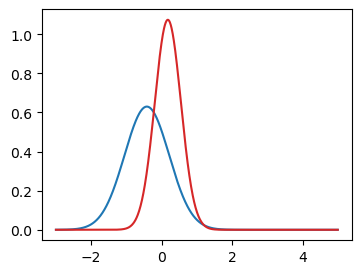

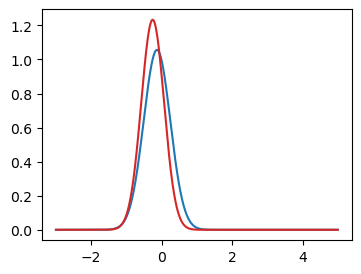

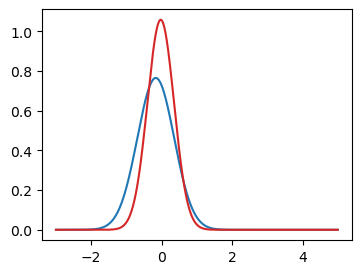

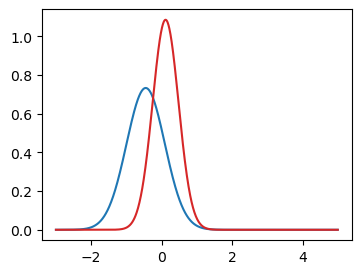

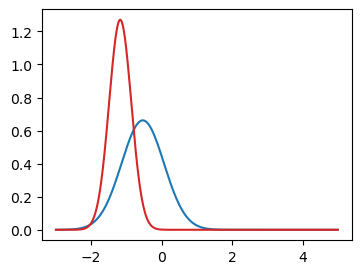

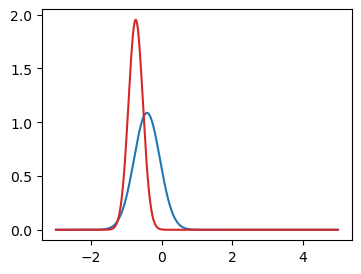

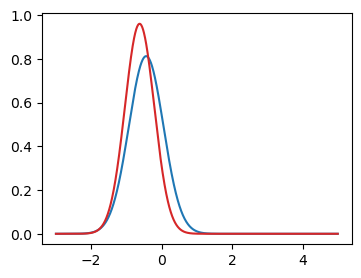

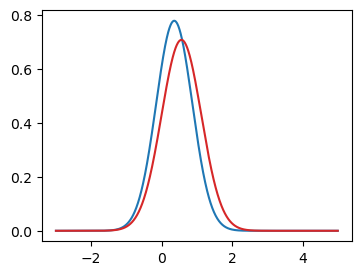

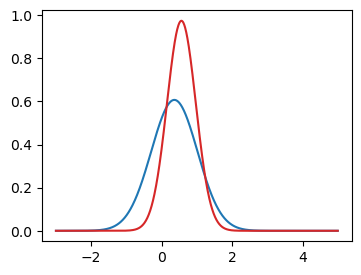

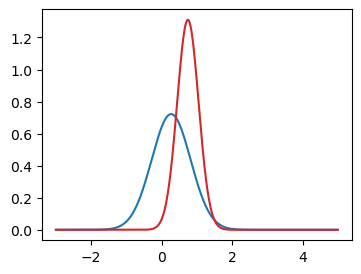

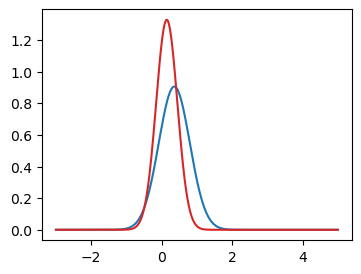

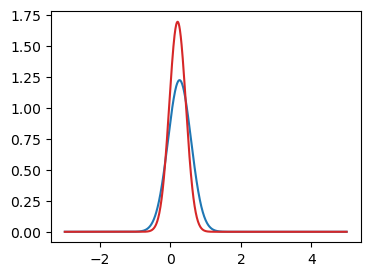

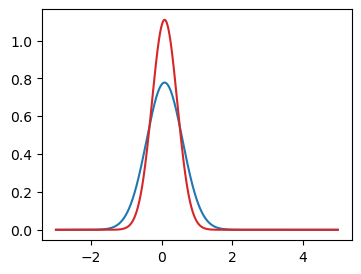

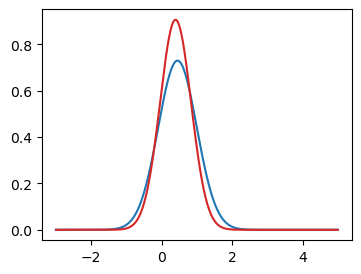

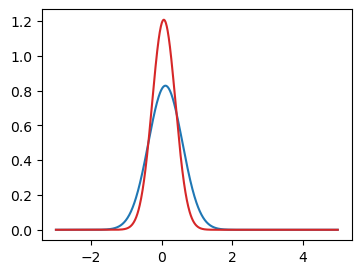

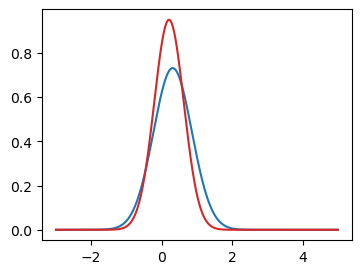

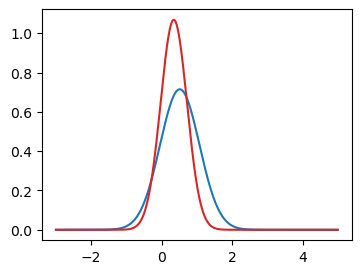

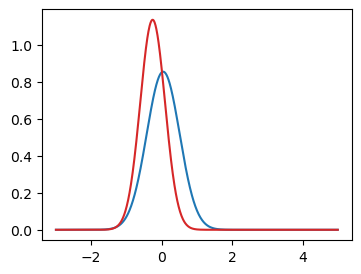

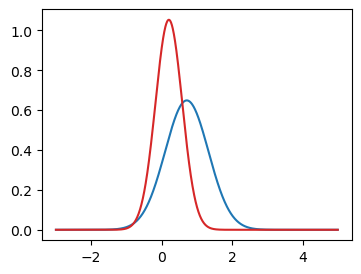

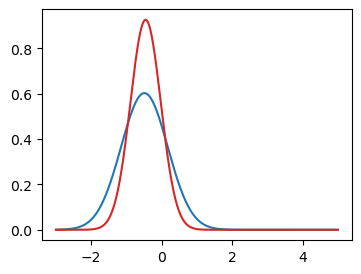

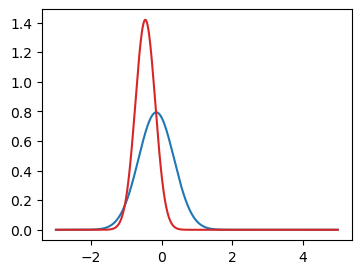

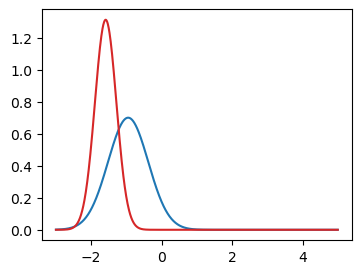

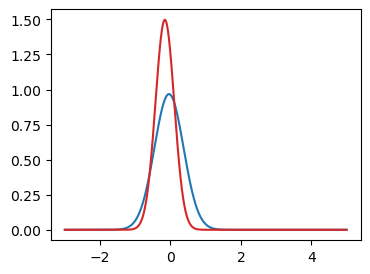

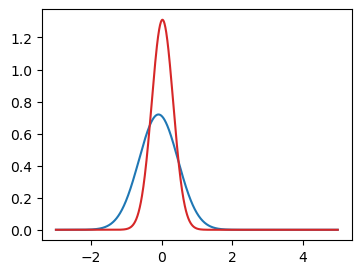

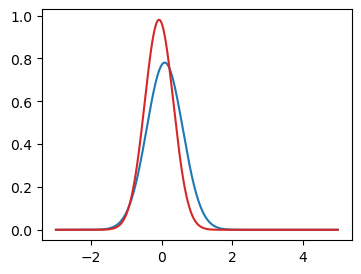

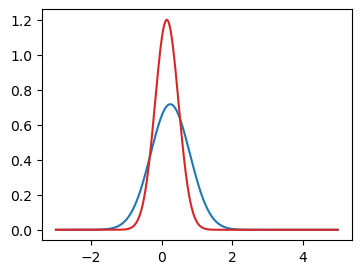

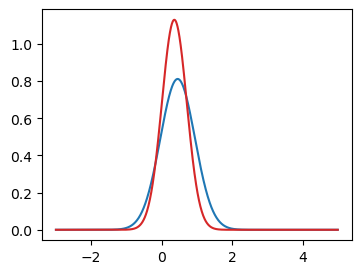

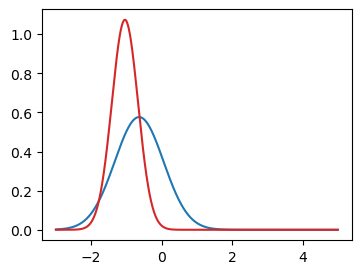

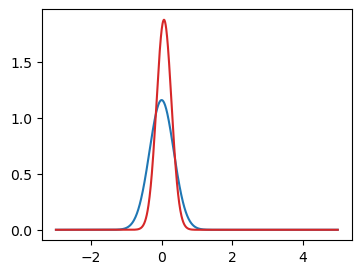

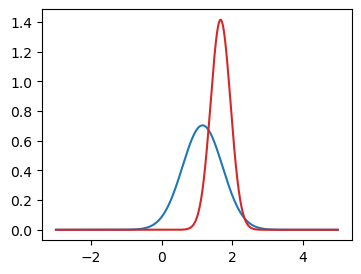

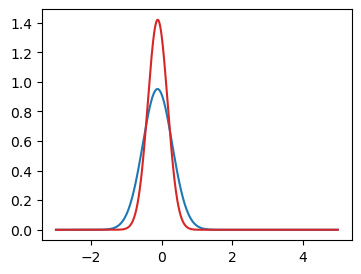

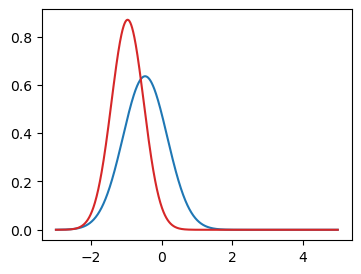

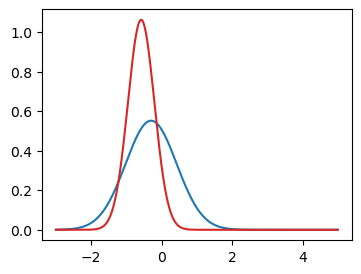

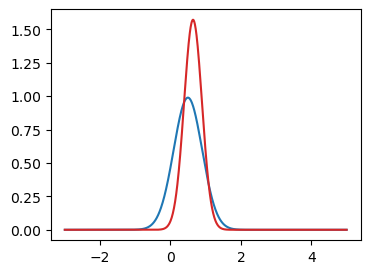

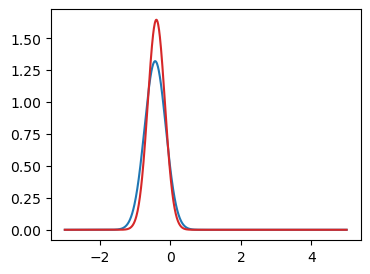

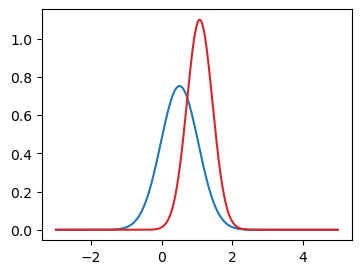

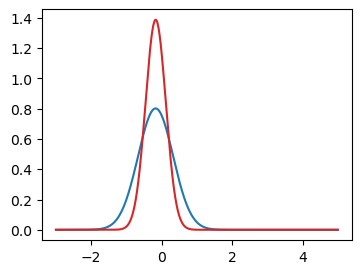

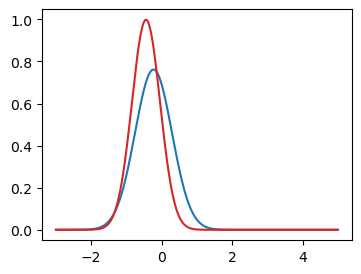

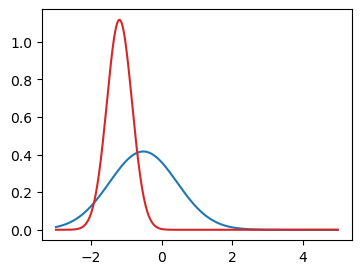

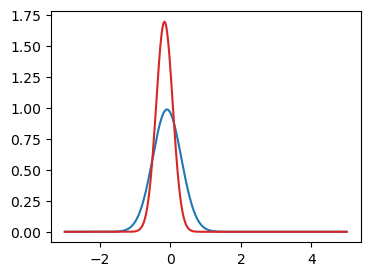

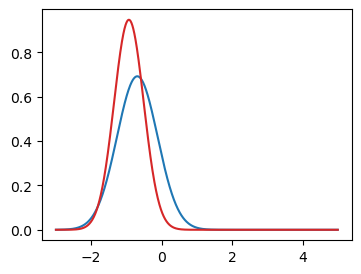

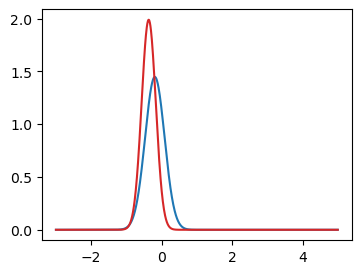

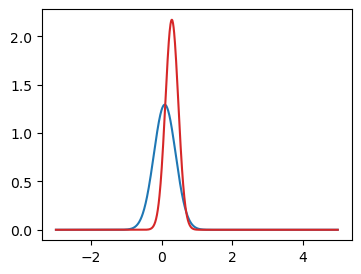

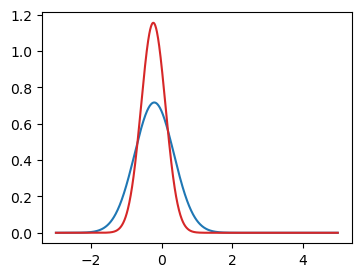

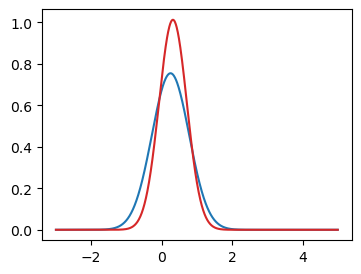

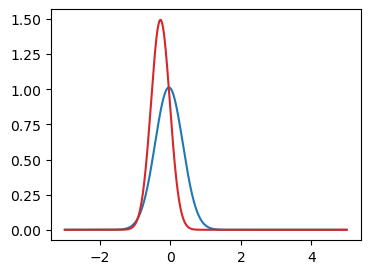

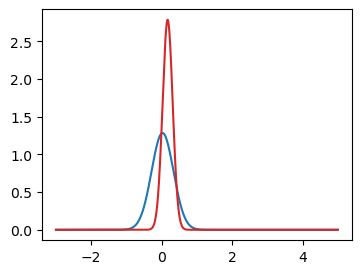

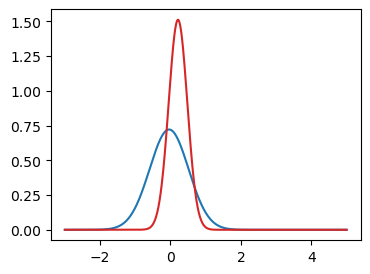

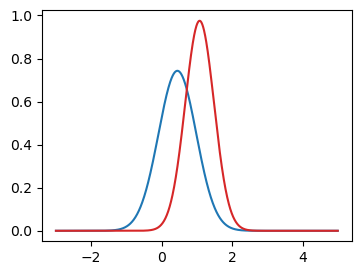

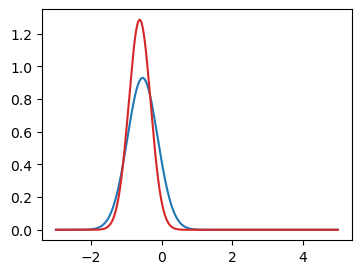

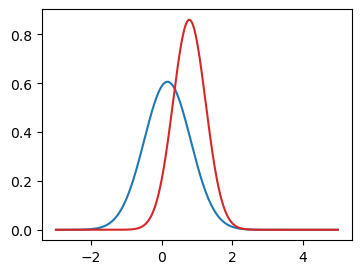

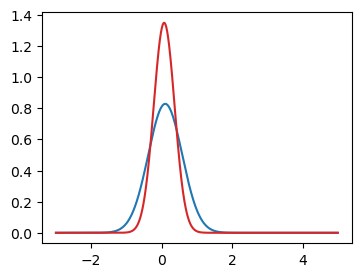

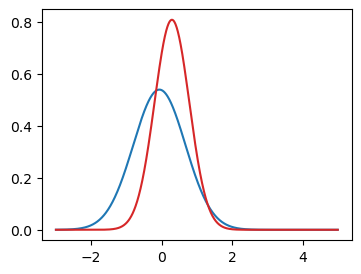

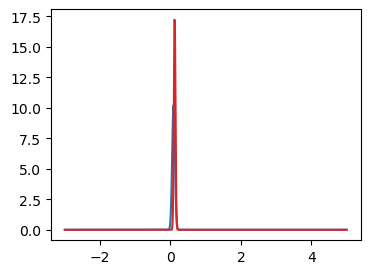

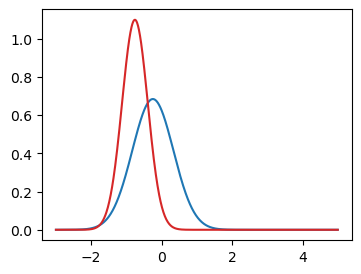

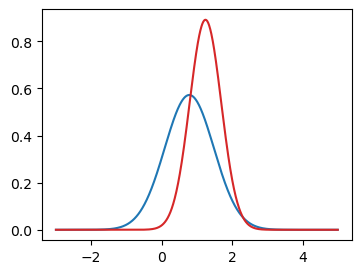

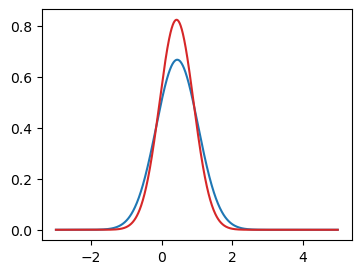

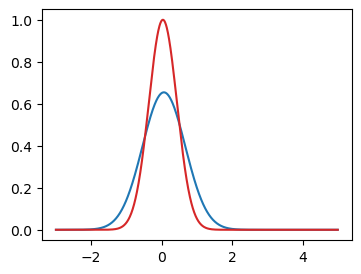

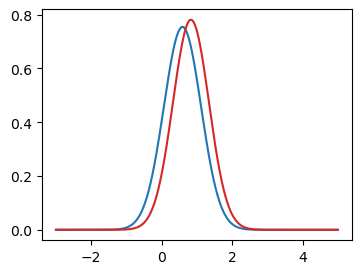

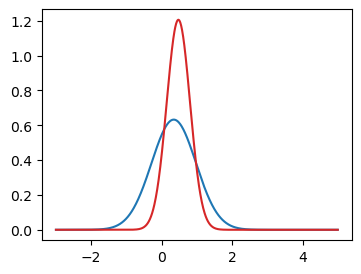

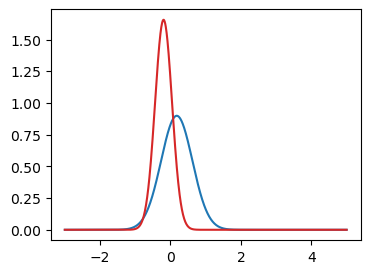

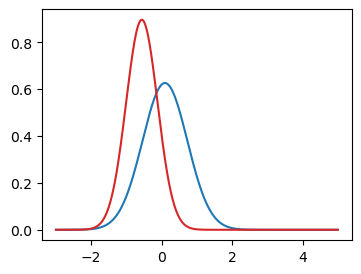

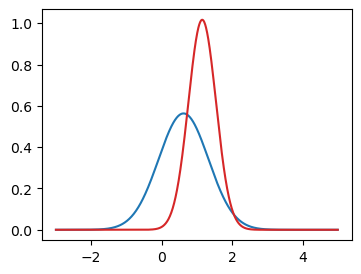

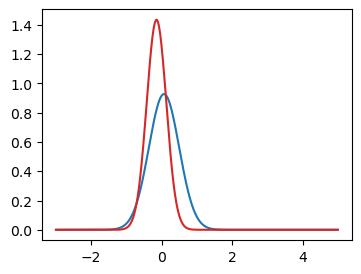

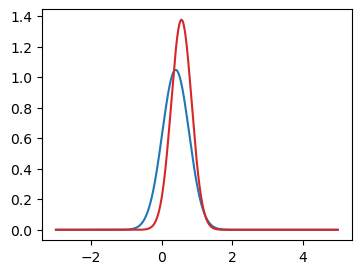

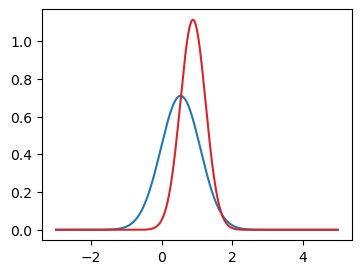

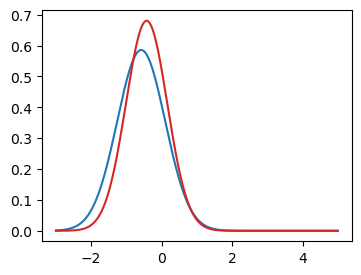

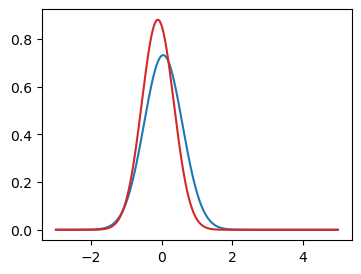

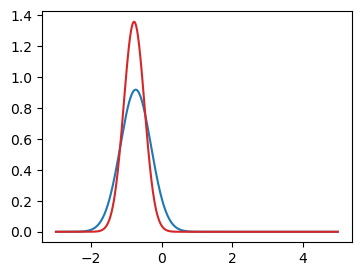

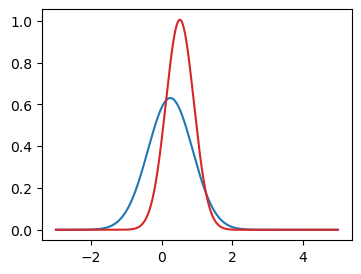

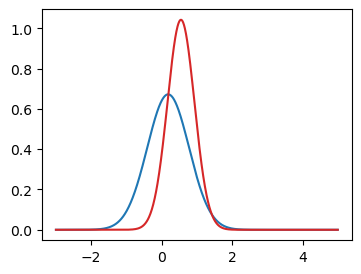

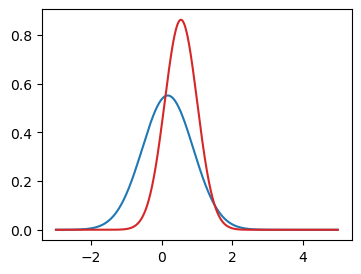

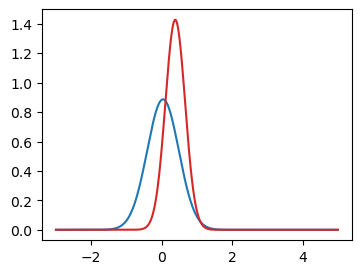

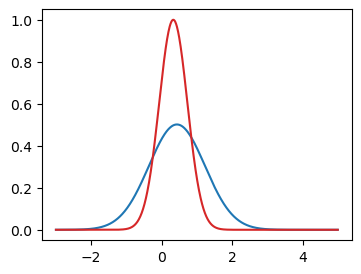

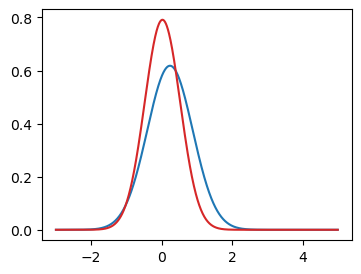

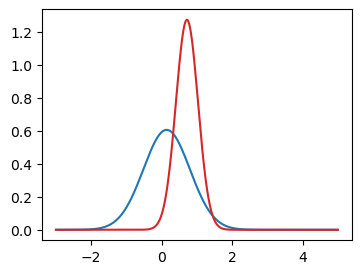

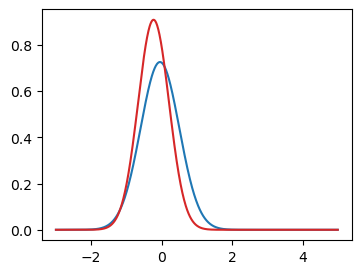

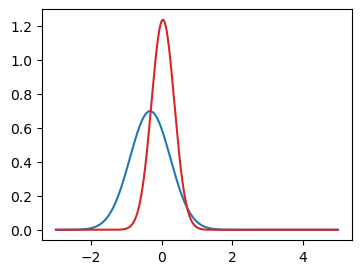

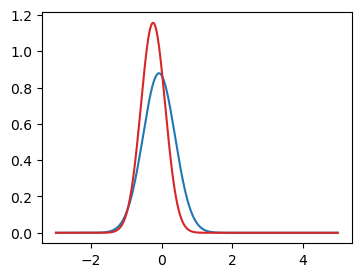

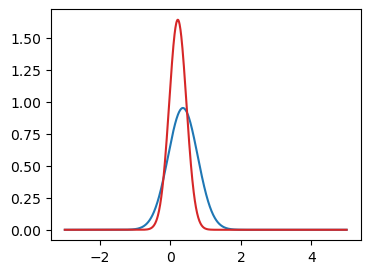

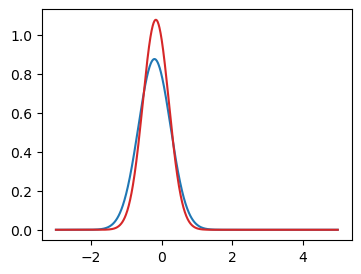

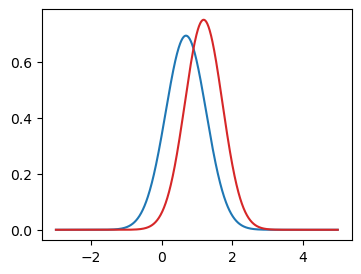

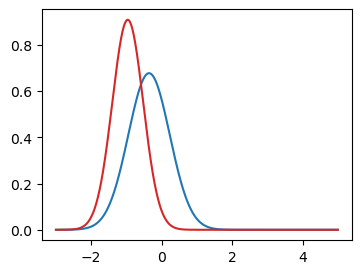

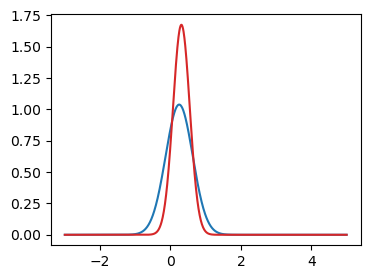

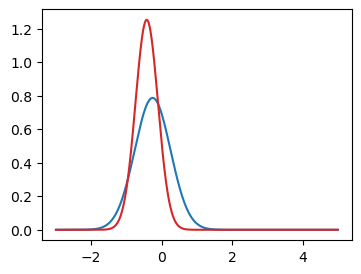

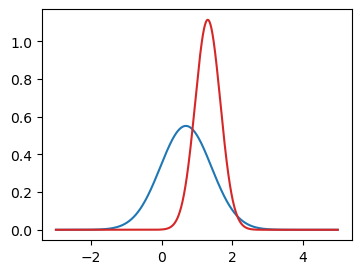

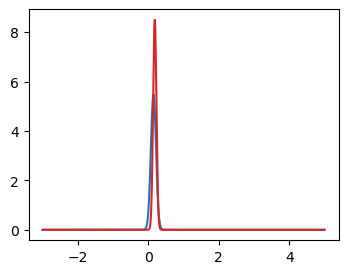

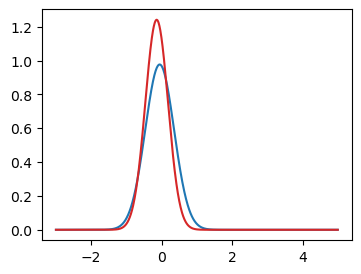


KeyboardInterrupt



In [13]:
for j in range(768):

    ncols, nrows = 1, 1
    fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

    x_axis = torch.linspace(start=-3, end=5, steps=1000)
    y_axis = utils.normal_pdf(x_axis, mus[0,j], torch.sqrt(var[0,j]))
    ax.plot(x_axis, y_axis, color="#1F77B4")


    x_axis = torch.linspace(start=-3, end=5, steps=1000)
    y_axis = utils.normal_pdf(x_axis, mus[1,j], torch.sqrt(var[1,j]))
    ax.plot(x_axis, y_axis, color="#D62728")

    plt.show()

In [14]:
import torchmetrics

log_probs_0 = _log_normal_diag(X_test, mus[:K], var[:K], eps=1e-6)
log_pi_0 = torch.log(pi_0.clamp_min(1e-6))[None, :]
log_joint_0 = log_pi_0 + log_probs_0
log_probs_0 = torch.logsumexp(log_joint_0, dim=1)

log_probs_1 = _log_normal_diag(X_test, mus, var, eps=1e-6)
log_pi_1 = torch.log(pi_1.clamp_min(1e-6))[None, :]
log_joint_1 = log_pi_1 + log_probs_1
log_probs_01 = torch.logsumexp(log_joint_1[:,:K], dim=1)
log_probs_11 = torch.logsumexp(log_joint_1[:,K:], dim=1)

R = 100

log_p_y0 = torch.stack([x.sum() for x in torch.split(log_probs_0,  lengths_test)])

log_p_y1 = torch.stack([
    (n.sum() + torch.logsumexp((a-n).unfold(0, R, 1).sum(1) - math.log(len(n) - R + 1), 0))
    for n, a in zip(torch.split(log_probs_01, lengths_test), torch.split(log_probs_11, lengths_test))
])

p1 = torch.sigmoid(log_p_y1 - log_p_y0)


In [15]:

auroc = torchmetrics.AUROC(task="binary")

print(auroc(p1, y_test).item())

0.5116737484931946


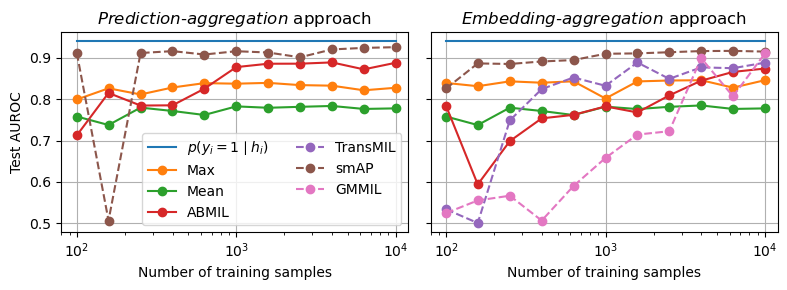

In [147]:
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
embedding_gmmil_aurocs = [0.5245983004570007, 0.5550840497016907, 0.5664970278739929, 0.5063696503639221, 0.5900250673294067, 0.6578624248504639, 0.7143468856811523, 0.7224209904670715, 0.899236261844635, 0.8066785335540771, 0.9104310870170593]

# Number of training samples comparison: Instance vs Embedding approaches
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
bayes_aurocs = [0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742]

# Instance approach data
instance_max_aurocs = [0.79922861, 0.82617551, 0.81138778, 0.82818407, 0.83871472, 0.8374024, 0.83935493, 0.8339535, 0.83258915, 0.82142228, 0.82751989]
instance_mean_aurocs = [0.75799811, 0.73751485, 0.77952754, 0.77141953, 0.76173103, 0.78252029, 0.77914345, 0.78147614, 0.78352463, 0.7763468, 0.77771914]
instance_attention_aurocs = [0.71253049, 0.8149966, 0.78454089, 0.78508896, 0.82515526, 0.8774966, 0.88565868, 0.88576275, 0.88885957, 0.87204719, 0.88799542]
instance_aurocs = [0.54418731, 0.49448657, 0.60938799, 0.90453953, 0.89152825, 0.92568898, 0.92719746, 0.92076778, 0.93211067, 0.93202257, 0.93477529]
instance_smap_aurocs = [0.911241, 0.506472, 0.911557, 0.916131, 0.907932, 0.915906, 0.912798, 0.901223, 0.920220, 0.923949, 0.925693]

# Embedding approach data
embedding_max_aurocs = [0.83920681, 0.83130884, 0.8430478, 0.83972704, 0.84314382, 0.80154121, 0.84288782, 0.84505439, 0.84580052, 0.82786, 0.84583652]
embedding_mean_aurocs = [0.75799805, 0.73737478, 0.77939558, 0.77136952, 0.76157498, 0.78188413, 0.77605063, 0.78147614, 0.78476489, 0.77635074, 0.77766311]
embedding_attention_aurocs = [0.78364861, 0.59374005, 0.69853681, 0.75359094, 0.76203912, 0.78248435, 0.76786065, 0.8089931, 0.84469223, 0.86586171, 0.87401581]
embedding_transformer_aurocs = [0.53374463, 0.50044215, 0.74862361, 0.82435507, 0.85234016, 0.83231711, 0.88865548, 0.84906542, 0.87685645, 0.87486798, 0.8882314]
embedding_smap_aurocs = [0.825767, 0.886403, 0.885079, 0.891080, 0.894557, 0.909737, 0.910661, 0.913466, 0.916263, 0.916715, 0.915010]

ncols, nrows = 2, 1
fig, axs = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

# Instance approach plot
axs[0].plot(N_trains, bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$")
axs[0].plot(N_trains, instance_max_aurocs, color="#FF7F0E", label="Max", marker="o")
axs[0].plot(N_trains, instance_mean_aurocs, color="#2CA02C", label="Mean", marker="o")
axs[0].plot(N_trains, instance_attention_aurocs, color="#D62728", label="ABMIL", marker="o")
axs[0].plot([], [], color="#9467BD", label="TransMIL", linestyle="--", marker="o")
axs[0].plot(N_trains, instance_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")
axs[0].plot([], [], color="#E377C2", label="GMMIL", linestyle="--", marker="o")
axs[0].set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
axs[0].set_xlabel("Number of training samples")
axs[0].set_ylabel("Test AUROC")
axs[0].set_xscale("log")
axs[0].set_xlim(80, 12000)
axs[0].legend(loc="lower right", ncols=2)
axs[0].grid()

# Embedding approach plot
axs[1].plot(N_trains, bayes_aurocs, color="#1F77B4")
axs[1].plot(N_trains, embedding_max_aurocs, color="#FF7F0E", marker="o")
axs[1].plot(N_trains, embedding_mean_aurocs, color="#2CA02C", marker="o")
axs[1].plot(N_trains, embedding_attention_aurocs, color="#D62728", marker="o")
axs[1].plot(N_trains, embedding_transformer_aurocs, color="#9467BD", linestyle="--", marker="o")
axs[1].plot(N_trains, embedding_smap_aurocs, color="#8C564B", linestyle="--", marker="o")
axs[1].plot(N_trains, embedding_gmmil_aurocs, color="#E377C2", linestyle="--", marker="o")

axs[1].set_title(r"$\it{Embedding}$-$\it{aggregation}$ approach")
axs[1].set_xlabel("Number of training samples")
axs[1].set_xscale("log")
axs[1].set_xlim(80, 12000)
# Remove legend from right plot
axs[1].grid()

fig.tight_layout()
fig.savefig("varying_training_set_size.pdf", bbox_inches="tight")
plt.show()


In [1]:
plt.plot(-loglik_hist[5:])
plt.yscale("log")
plt.show()

NameError: name 'plt' is not defined